In [1]:
import os, time, json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_recall_fscore_support
)

import matplotlib.pyplot as plt
import seaborn as sns

# PATHS
PROJECT_ROOT = Path("/Users/syedadnanahmad/Downloads/AI_TUMOUR_detection")
EMB_ROOT     = PROJECT_ROOT / "embeddings"
IDX_CSV      = PROJECT_ROOT / "notebooks" / "slide_index.csv"
MODEL_DIR    = PROJECT_ROOT / "models"
RESULTS_DIR  = PROJECT_ROOT / "results"

MODEL_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# DEVICE
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

df_index = pd.read_csv(IDX_CSV)


Device: mps


In [2]:
OSCC_CLASSES = ["wdoscc", "mdoscc", "pdoscc"]
NORMAL_CLASS = ["normal"]

def make_stage1_df(df):
    mask = df["class"].isin(OSCC_CLASSES + NORMAL_CLASS)
    df2 = df[mask].copy().reset_index(drop=True)
    df2["binary_label"] = df2["class"].apply(lambda c: 1 if c in OSCC_CLASSES else 0)
    return df2

df_stage1 = make_stage1_df(df_index)
print(df_stage1.groupby(["split", "binary_label"]).size())


split  binary_label
test   0                14
       1               105
train  0                14
       1               104
val    0                14
       1               104
dtype: int64


In [3]:
class BinarySlideDataset(Dataset):
    def __init__(self, df, split):
        self.df = df[df["split"] == split].reset_index(drop=True)
        self.items = []

        for _, row in self.df.iterrows():
            slide = row["slide_id"]
            cls   = row["class"]
            label = int(row["binary_label"])

            emb_path  = EMB_ROOT / split / cls / f"{slide}.npy"
            if emb_path.exists():
                self.items.append({
                    "emb_path": emb_path,
                    "label": label,
                    "slide_id": slide,
                    "class": cls
                })

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        it = self.items[idx]
        emb = torch.from_numpy(np.load(it["emb_path"]).astype(np.float32))
        label = torch.tensor(it["label"], dtype=torch.long)
        return {"emb": emb, "label": label}


In [4]:
train_ds = BinarySlideDataset(df_stage1, "train")
val_ds   = BinarySlideDataset(df_stage1, "val")
test_ds  = BinarySlideDataset(df_stage1, "test")

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, collate_fn=lambda x: x[0])
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False, collate_fn=lambda x: x[0])
test_loader  = DataLoader(test_ds, batch_size=1, shuffle=False, collate_fn=lambda x: x[0])

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

# STRONG WEIGHT BOOST for NORMAL class
class_weights = torch.tensor([3.0, 1.0], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)


Train: 118 Val: 118 Test: 119


In [5]:
class AttentionMIL(nn.Module):
    def __init__(self, emb_dim=512, hidden_dim=256, dropout=0.4):
        super().__init__()
        
        self.V = nn.Linear(emb_dim, hidden_dim)
        self.U = nn.Linear(emb_dim, hidden_dim)
        self.w = nn.Linear(hidden_dim, 1)

        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, emb_dim//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim//2, 2)
        )

    def forward(self, H):
        Vh = torch.tanh(self.V(H))
        Uh = torch.sigmoid(self.U(H))
        A  = self.w(Vh * Uh).squeeze(1)       
        attn = torch.softmax(A, dim=0)        

        agg = torch.sum(attn.unsqueeze(1) * H, dim=0)
        logits = self.classifier(agg)
        return logits.unsqueeze(0)


In [6]:
def train_epoch(model, loader, optimizer):
    model.train()
    losses, y_true, y_pred = [], [], []

    for batch in loader:
        emb = batch["emb"].to(device)
        label = batch["label"].to(device)

        optimizer.zero_grad()
        logits = model(emb)
        loss = criterion(logits, label.unsqueeze(0))
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()[0]
        y_pred.append(np.argmax(probs))
        y_true.append(int(label))

    acc = accuracy_score(y_true, y_pred)
    f1  = precision_recall_fscore_support(y_true, y_pred, average='macro')[2]
    return np.mean(losses), acc, f1


def val_epoch(model, loader):
    model.eval()
    losses, y_true, y_pred = [], [], []

    with torch.no_grad():
        for batch in loader:
            emb = batch["emb"].to(device)
            label = batch["label"].to(device)

            logits = model(emb)
            loss = criterion(logits, label.unsqueeze(0))
            losses.append(loss.item())

            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
            y_pred.append(np.argmax(probs))
            y_true.append(int(label))

    acc = accuracy_score(y_true, y_pred)
    f1  = precision_recall_fscore_support(y_true, y_pred, average='macro')[2]
    return np.mean(losses), acc, f1


In [8]:
model_stage1 = AttentionMIL().to(device)
optimizer = torch.optim.AdamW(model_stage1.parameters(), lr=5e-5, weight_decay=1e-5)

best_f1 = -1
patience = 6
no_imp = 0

for epoch in range(1, 40):
    tr_loss, tr_acc, tr_f1 = train_epoch(model_stage1, train_loader, optimizer)
    va_loss, va_acc, va_f1 = val_epoch(model_stage1, val_loader)

    print(f"Epoch {epoch}: Val F1 = {va_f1:.3f}, Val Acc = {va_acc:.3f}")

    if va_f1 > best_f1:
        best_f1 = va_f1
        no_imp = 0
        torch.save(model_stage1.state_dict(), MODEL_DIR/"stage1_binary_improved.pth")
        print("Saved best model.")
    # else:
    #     no_imp += 1
    #     if no_imp >= patience:
    #         print("Early stopping.")
    #         break


/opt/anaconda3/envs/oral_msc/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 1: Val F1 = 0.468, Val Acc = 0.881
Saved best model.


/opt/anaconda3/envs/oral_msc/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/oral_msc/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 2: Val F1 = 0.468, Val Acc = 0.881


/opt/anaconda3/envs/oral_msc/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/oral_msc/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


...

Epoch 14: Val F1 = 0.468, Val Acc = 0.881


/opt/anaconda3/envs/oral_msc/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/oral_msc/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 15: Val F1 = 0.468, Val Acc = 0.881


/opt/anaconda3/envs/oral_msc/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 16: Val F1 = 0.468, Val Acc = 0.881
Epoch 17: Val F1 = 0.537, Val Acc = 0.890
Saved best model.
Epoch 18: Val F1 = 0.699, Val Acc = 0.915
Saved best model.
Epoch 19: Val F1 = 0.817, Val Acc = 0.941
Saved best model.
Epoch 20: Val F1 = 0.850, Val Acc = 0.949
Saved best model.
Epoch 21: Val F1 = 0.699, Val Acc = 0.915
Epoch 22: Val F1 = 0.907, Val Acc = 0.966
Saved best model.
Epoch 23: Val F1 = 0.907, Val Acc = 0.966
Epoch 24: Val F1 = 0.907, Val Acc = 0.966
Epoch 25: Val F1 = 0.907, Val Acc = 0.966
Epoch 26: Val F1 = 0.888, Val Acc = 0.958
Epoch 27: Val F1 = 0.888, Val Acc = 0.958
Epoch 28: Val F1 = 0.888, Val Acc = 0.958
Epoch 29: Val F1 = 0.888, Val Acc = 0.958
Epoch 30: Val F1 = 0.888, Val Acc = 0.958
Epoch 31: Val F1 = 0.888, Val Acc = 0.958
Epoch 32: Val F1 = 0.888, Val Acc = 0.958
Epoch 33: Val F1 = 0.888, Val Acc = 0.958
Epoch 34: Val F1 = 0.888, Val Acc = 0.958
Epoch 35: Val F1 = 0.888, Val Acc = 0.958
Epoch 36: Val F1 = 0.888, Val Acc = 0.958
Epoch 37: Val F1 = 0.888, Va

=== TEST REPORT (with threshold=0.65) ===
              precision    recall  f1-score   support

      normal       0.90      0.64      0.75        14
        oscc       0.95      0.99      0.97       105

    accuracy                           0.95       119
   macro avg       0.93      0.82      0.86       119
weighted avg       0.95      0.95      0.95       119



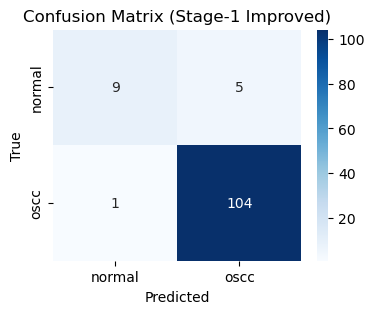

In [9]:
# Load best model
model_stage1 = AttentionMIL().to(device)
model_stage1.load_state_dict(torch.load(MODEL_DIR/"stage1_binary_improved.pth", map_location=device))
model_stage1.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        emb = batch["emb"].to(device)
        label = batch["label"].item()

        logits = model_stage1(emb)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

        # APPLY THRESHOLD
        if probs[1] > 0.65:
            pred = 1
        else:
            pred = 0

        y_true.append(label)
        y_pred.append(pred)

print("=== TEST REPORT (with threshold=0.65) ===")
print(classification_report(y_true, y_pred, target_names=["normal","oscc"], zero_division=0))


from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["normal","oscc"],
            yticklabels=["normal","oscc"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Stage-1 Improved)")
plt.show()

